# Mediana dla obrazu kolorowego

Idea filtracji medianowej jest dość prosta dla obrazów w odcieniach szarości.
Dla obrazów kolorowych trudniej jest określić kryterium wg. którego szeregowane będą wartości, z których wyznaczana będzie mediana.

Jedną z możliwości wykonania filtracji medianowej dla obrazów kolorowych (na podstawie *The Image Processing Handbook*, J. Russ) jest wykorzystanie następującej definicji mediany:
``mediana to ten piksel z otoczenia, którego odległość do innych pikseli z otoczenia jest najmniejsza''.
Jako miarę odległości wykorzystujemy pierwiastek z sumy kwadratów różnic poszczególnych składowych R,G,B.
Zatem odległość między dwoma pikselami wyraża się wzorem:
\begin{equation}
dRGB = \sqrt{(R_1-R_2)^2+(G_1-G_2)^2+(B_1-B_2)^2}
\end{equation}

Warto zwrócić uwagę, że istnieje wiele możliwości zdefiniowania porównywania wielkości wektorowych (jeden piksel to wektor o trzech składowych).
Można zamiast odległości wykorzystać kąt albo połączyć oba parametry.
Ponadto istnieje możliwość dodania do wektora dodatkowych składowych - tak aby lepiej opisać piksel.

Celem zadania jest implementacja opisanego algorytmu.

1. Wczytaj obraz *lenaRGBSzum.png* (dostępny na git).
2. Zdefiniuj rozmiar okna.
3. Wykonaj pętle po pikselach, dla których okno jest zdefiniowane (pomiń brzeg obrazu).
4. Dla każdego piksela pobierz okno o właściwym rozmiarze.
5. Wykonaj pętle po oknie, wewnątrz której obliczona zostanie suma odległości.
    - Obliczanie różnicy: `window - window[rowWin, colWin]`.
    - Obliczanie kwadratów: `np.square`.
    - Obliczanie pierwiastka: `np.sqrt`.
    - Obliczanie sumy metodą `.sum`.
6. Po obliczeniu macierzy odległości wyznacz argument elementu minimalnego.
Wykorzystaj funkcję `np.argmin`.
Argument funkcji zostanie spłaszczony, jeśli ma więcej niż jeden wymiar.
Aby przekonwertować spłaszczony indeks na indeks macierzy wykorzystaj funkcję `np.unravel_index`.
7. Przypisz odpowiedni wektor wartości do piksela obrazu wynikowego.
8. Wyświetl obraz oryginalny i przefiltrowany.
9. Przeprowadź dwa eksperymenty - dla obrazu _lenaRGB_ oraz _lenaRGBszum_.

In [1]:
import cv2
import os
import requests
from matplotlib import pyplot as plt
import numpy as np
from scipy import signal

url = "https://raw.githubusercontent.com/vision-agh/poc_sw/master/06_Context/"

fileNames = ["lenaRGB.png", "lenaRGBSzum.png"]
for fileName in fileNames:
    if not os.path.exists(fileName):
        r = requests.get(url + fileName, allow_redirects=True)
        open(fileName, "wb").write(r.content)

images = {}
for fileName in fileNames:
    fileNameBase = ".".join(fileName.split(".")[:-1])
    images[fileNameBase] = cv2.cvtColor(
        cv2.imread(fileName, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB
    )

In [2]:
def medianRGB(image, size):
    result = np.zeros_like(image)
    height, width, _ = result.shape

    for i in range(height):
        for j in range(width):
            w_x0 = np.clip(i - size // 2, 0, height)
            w_x1 = np.clip(i + size // 2 + 1, 0, height)
            w_y0 = np.clip(j - size // 2, 0, width)
            w_y1 = np.clip(j + size // 2 + 1, 0, width)

            window = image[w_x0:w_x1, w_y0:w_y1].astype(np.float32)
            window_height, window_width, _ = window.shape

            d_rgb = np.zeros((window_height, window_width))
            for row in range(window_height):
                for col in range(window_width):
                    d_rgb[row, col] = np.sqrt((window - window[row, col]) ** 2).sum()

            arg = np.unravel_index(np.argmin(d_rgb), d_rgb.shape)
            result[i, j] = window[arg]

    return result


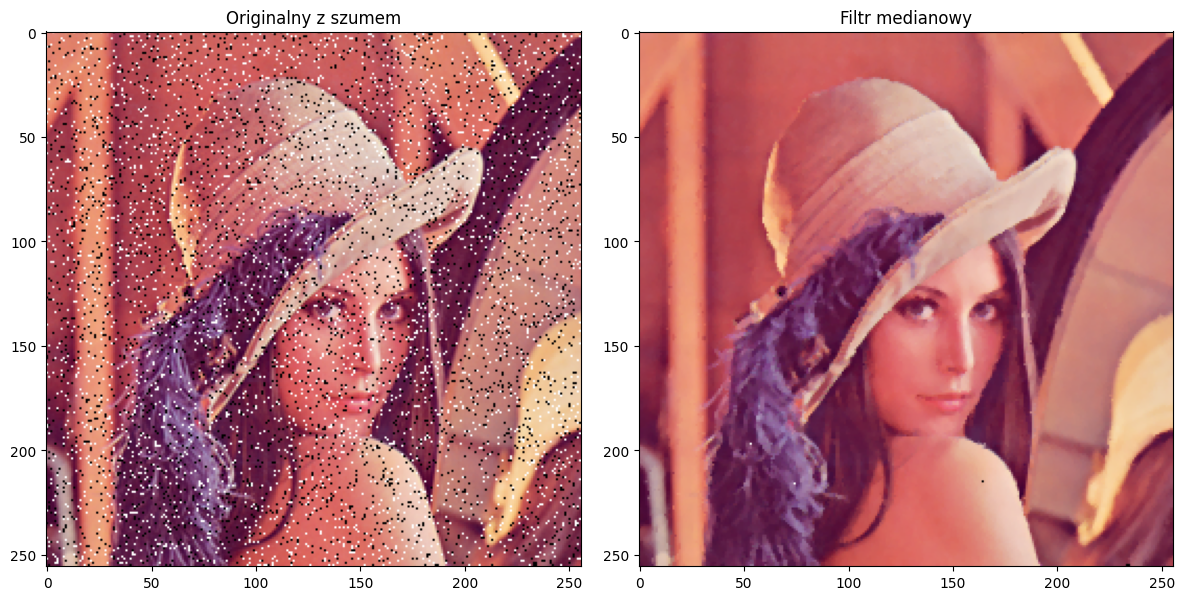

In [3]:
N = 3
result = images["lenaRGBSzum"]

f, axs = plt.subplots(1, 2)
f.set_size_inches(12, 8)
f.tight_layout()

axs[0].imshow(result)
axs[0].set_title("Originalny z szumem")

image_filtered = medianRGB(result, N)
axs[1].imshow(image_filtered)
axs[1].set_title("Filtr medianowy")

plt.show()

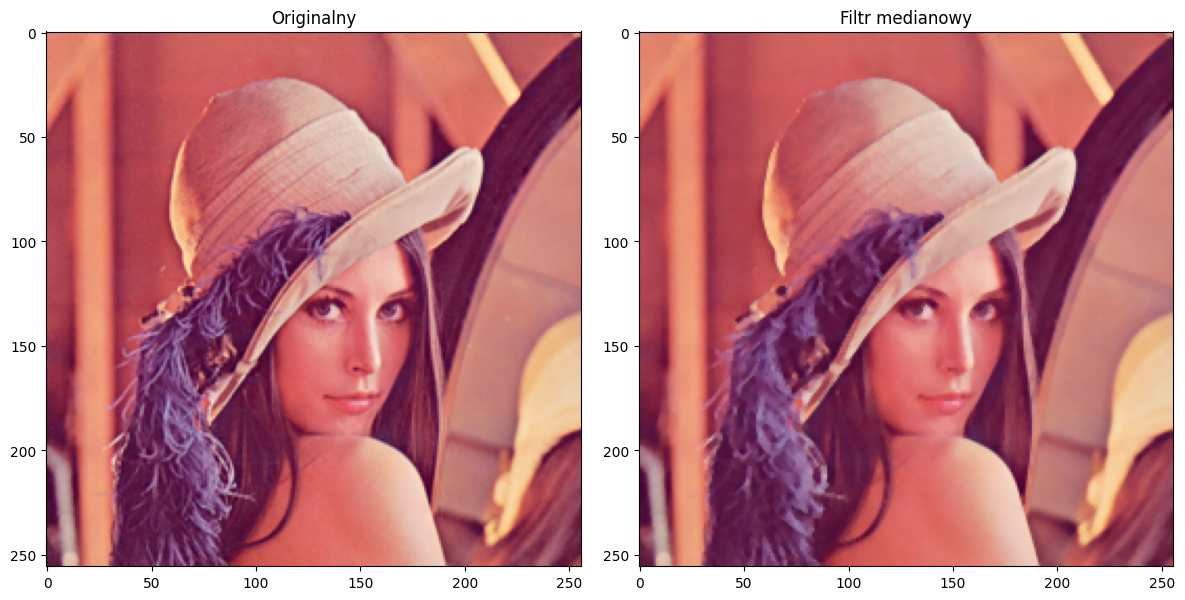

In [4]:
N = 3
result = images["lenaRGB"]

f, axs = plt.subplots(1, 2)
f.set_size_inches(12, 8)
f.tight_layout()

axs[0].imshow(result)
axs[0].set_title("Originalny")

image_filtered = medianRGB(result, N)
axs[1].imshow(image_filtered)
axs[1].set_title("Filtr medianowy")

plt.show()